# UPI Fraud Detection — Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("../data/raw/upi_transactions.csv", parse_dates=["timestamp"])
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()
df["is_fraud"] = (df["transaction_status"] == "Fraud").astype(int)

df.shape

(150000, 17)

## 1. Basic Overview

In [2]:
df.head()

,transaction_id,sender_account_name,receiver_account_name,sender_bank,receiver_bank,transaction_amount,timestamp,transaction_location,device_type,is_new_beneficiary,location_mismatch_flag,device_change_flag,transactions_last_24h,transaction_status,hour,day_of_week,is_fraud
0,TXN159770,U.C.,M.S.,HDFC,Axis,1373.37,2025-09-01 11:31:33,Jaipur,Web,0,0,0,3,No Fraud,11,Monday,0
1,TXN121362,S.Y.,T.S.,HDFC,Canara,25007.35,2025-12-22 00:07:00,Rural-UP,Android,1,0,0,6,Fraud,0,Monday,1
2,TXN227324,W.K.,G.K.,Union Bank,Axis,1032.29,2025-02-06 17:52:42,Hyderabad,iOS,0,0,0,1,No Fraud,17,Thursday,0
3,TXN240509,G.S.,G.G.,Canara,IDFC First,2297.18,2025-12-14 06:06:17,Rural-MP,iOS,0,0,0,1,No Fraud,6,Sunday,0
4,TXN244297,A.N.,C.R.,BOB,PNB,44751.58,2025-03-21 01:43:56,Rural-MP,Web,1,0,1,9,Fraud,1,Friday,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   transaction_id          150000 non-null  str           
 1   sender_account_name     150000 non-null  str           
 2   receiver_account_name   150000 non-null  str           
 3   sender_bank             150000 non-null  str           
 4   receiver_bank           150000 non-null  str           
 5   transaction_amount      150000 non-null  float64       
 6   timestamp               150000 non-null  datetime64[us]
 7   transaction_location    150000 non-null  str           
 8   device_type             150000 non-null  str           
 9   is_new_beneficiary      150000 non-null  int64         
 10  location_mismatch_flag  150000 non-null  int64         
 11  device_change_flag      150000 non-null  int64         
 12  transactions_last_24h   150000 non-null  

In [4]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


transaction_id            0
sender_account_name       0
receiver_account_name     0
sender_bank               0
receiver_bank             0
transaction_amount        0
timestamp                 0
transaction_location      0
device_type               0
is_new_beneficiary        0
location_mismatch_flag    0
device_change_flag        0
transactions_last_24h     0
transaction_status        0
hour                      0
day_of_week               0
is_fraud                  0
dtype: int64

## 2. Class Imbalance


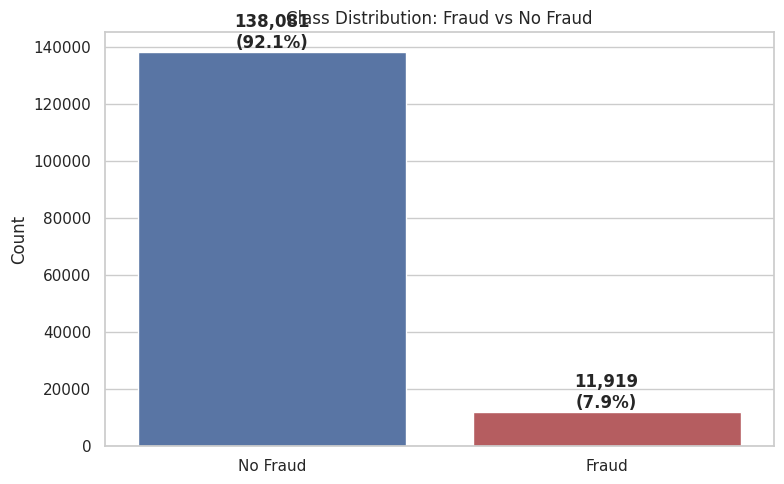

In [5]:
counts = df["transaction_status"].value_counts()
pct = df["transaction_status"].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
sns.countplot(data=df, x="transaction_status", hue="transaction_status",
              palette={"No Fraud": "#4C72B0", "Fraud": "#C44E52"}, legend=False, ax=ax)
for i, v in enumerate(counts):
    ax.text(i, v + 1500, f"{v:,}\n({pct.iloc[i]:.1f}%)", ha="center", fontweight="bold")
ax.set_title("Class Distribution: Fraud vs No Fraud")
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/figures/01_class_imbalance.png", dpi=150)
plt.show()

## 3. Transaction Amount Distribution


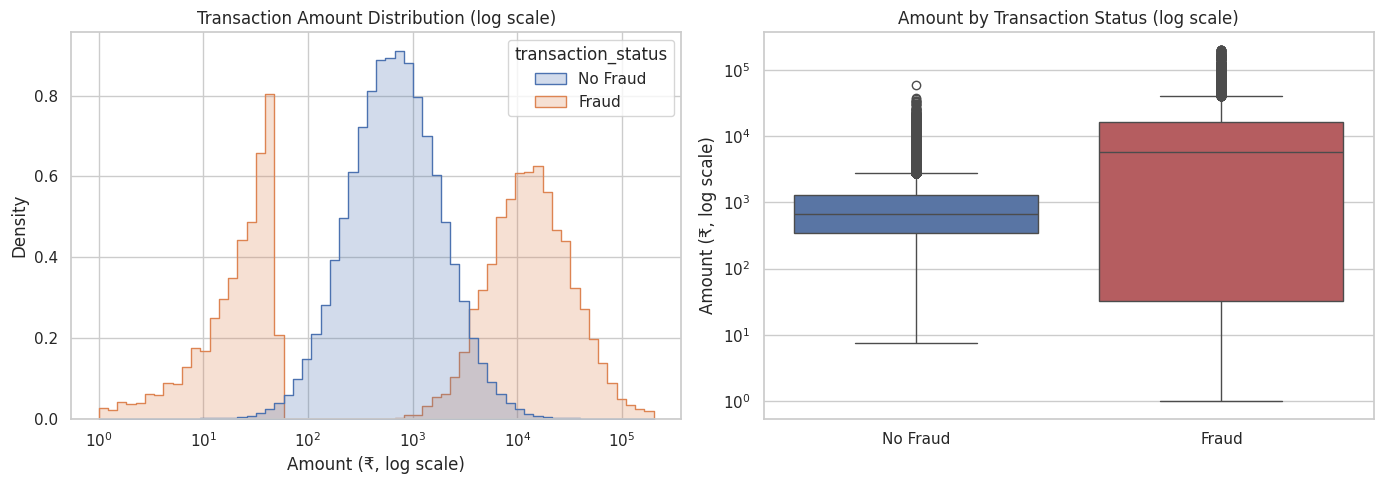

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="transaction_amount", hue="transaction_status", bins=60,
             log_scale=True, element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Transaction Amount Distribution (log scale)")
axes[0].set_xlabel("Amount (₹, log scale)")

sns.boxplot(data=df, x="transaction_status", y="transaction_amount", hue="transaction_status",
            palette={"No Fraud": "#4C72B0", "Fraud": "#C44E52"}, legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Amount by Transaction Status (log scale)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Amount (₹, log scale)")

plt.tight_layout()
plt.savefig("../reports/figures/02_amount_distribution.png", dpi=150)
plt.show()

In [7]:
df.groupby("transaction_status")["transaction_amount"].describe()

,count,mean,std,min,25%,50%,75%,max
transaction_status,,,,,,,,
Fraud,11919.0,12191.909008,19482.589211,1.00,32.665,5748.86,16196.035,200000.00
No Fraud,138081.0,1096.770881,1424.286824,7.59,339.300,665.63,1307.360,58634.83


## 4. Time-Based Patterns


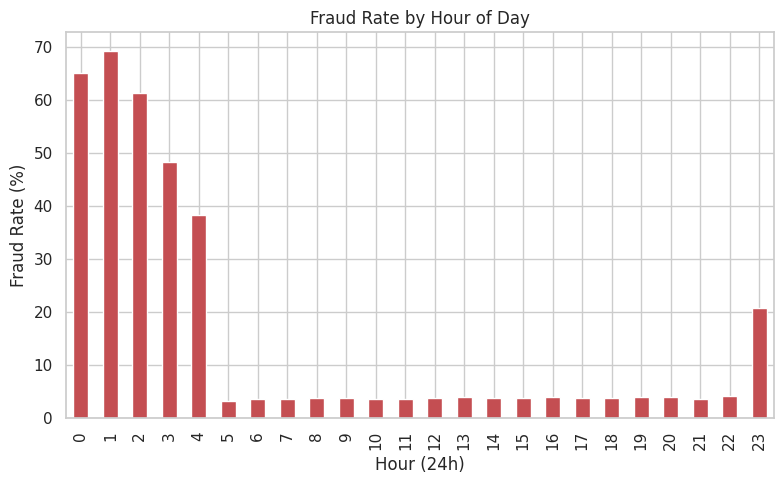

In [8]:
fraud_rate_by_hour = df.groupby("hour")["is_fraud"].mean() * 100

fig, ax = plt.subplots()
fraud_rate_by_hour.plot(kind="bar", color="#C44E52", ax=ax)
ax.set_title("Fraud Rate by Hour of Day")
ax.set_xlabel("Hour (24h)")
ax.set_ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.savefig("../reports/figures/03_fraud_rate_by_hour.png", dpi=150)
plt.show()

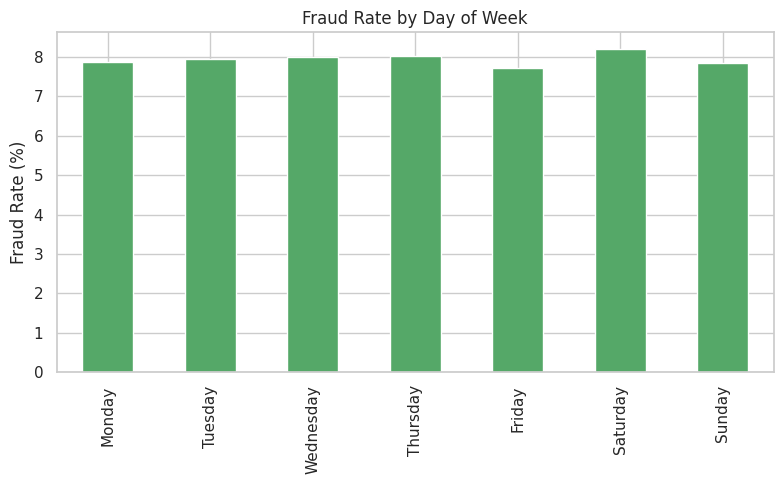

In [9]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
fraud_rate_by_day = df.groupby("day_of_week")["is_fraud"].mean().reindex(day_order) * 100

fig, ax = plt.subplots()
fraud_rate_by_day.plot(kind="bar", color="#55A868", ax=ax)
ax.set_title("Fraud Rate by Day of Week")
ax.set_ylabel("Fraud Rate (%)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../reports/figures/04_fraud_rate_by_day.png", dpi=150)
plt.show()

## 5. Behavioral / Contextual Flags
These are the strongest expected fraud signals: new beneficiaries, device changes, location mismatches, and transaction velocity.

In [10]:
flags = ["is_new_beneficiary", "location_mismatch_flag", "device_change_flag"]
flag_fraud_rate = pd.DataFrame({
    flag: df.groupby(flag)["is_fraud"].mean() * 100 for flag in flags
}).T
flag_fraud_rate.columns = ["Flag = 0 (%)", "Flag = 1 (%)"]
flag_fraud_rate

,Flag = 0 (%),Flag = 1 (%)
is_new_beneficiary,3.344359,31.824559
location_mismatch_flag,4.300002,47.291880
device_change_flag,4.754625,39.087714


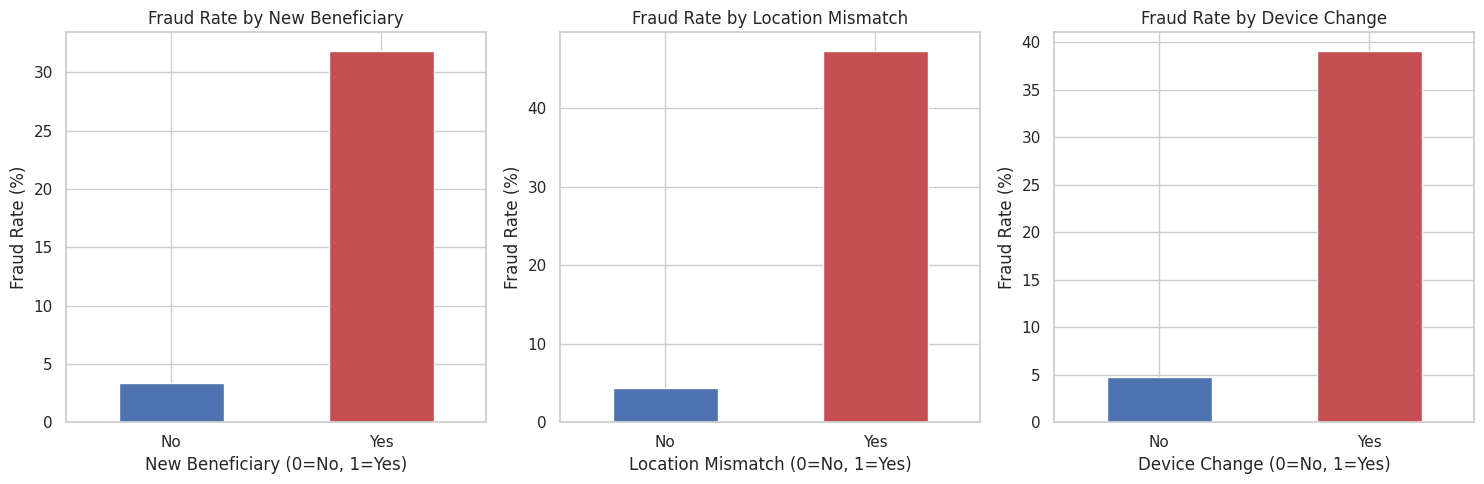

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["New Beneficiary", "Location Mismatch", "Device Change"]

for ax, flag, title in zip(axes, flags, titles):
    rates = df.groupby(flag)["is_fraud"].mean() * 100
    rates.plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
    ax.set_title(f"Fraud Rate by {title}")
    ax.set_xlabel(f"{title} (0=No, 1=Yes)")
    ax.set_ylabel("Fraud Rate (%)")
    ax.set_xticklabels(["No", "Yes"], rotation=0)

plt.tight_layout()
plt.savefig("../reports/figures/05_behavioral_flags.png", dpi=150)
plt.show()

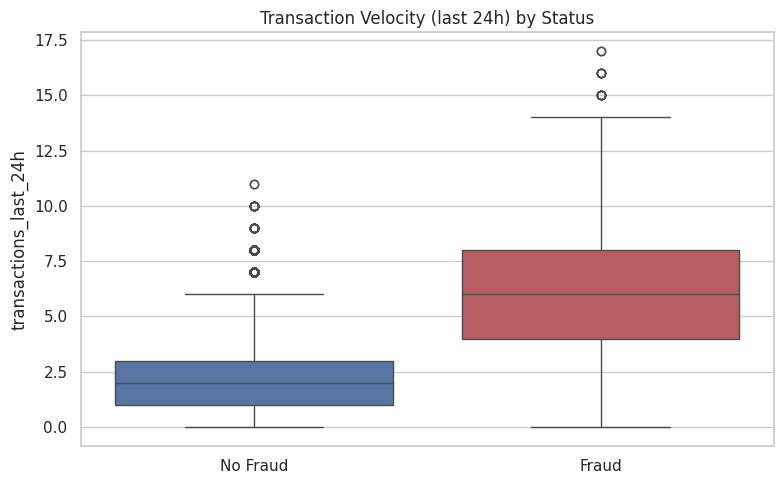

In [12]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="transaction_status", y="transactions_last_24h", hue="transaction_status",
            palette={"No Fraud": "#4C72B0", "Fraud": "#C44E52"}, legend=False, ax=ax)
ax.set_title("Transaction Velocity (last 24h) by Status")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../reports/figures/06_velocity.png", dpi=150)
plt.show()

## 6. Categorical Patterns — Device, Bank, Location


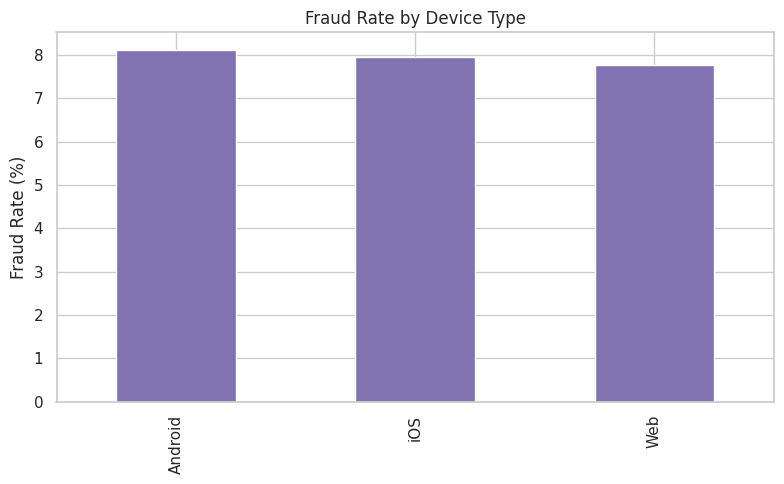

In [13]:
fig, ax = plt.subplots()
device_fraud = df.groupby("device_type")["is_fraud"].mean().sort_values(ascending=False) * 100
device_fraud.plot(kind="bar", color="#8172B2", ax=ax)
ax.set_title("Fraud Rate by Device Type")
ax.set_ylabel("Fraud Rate (%)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../reports/figures/07_fraud_by_device.png", dpi=150)
plt.show()

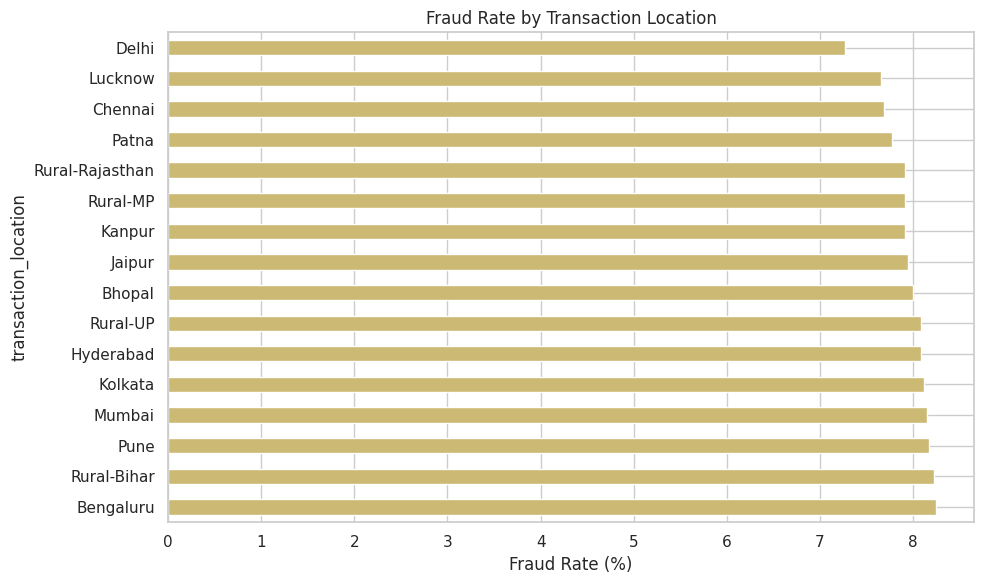

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
loc_fraud = df.groupby("transaction_location")["is_fraud"].mean().sort_values(ascending=False) * 100
loc_fraud.plot(kind="barh", color="#CCB974", ax=ax)
ax.set_title("Fraud Rate by Transaction Location")
ax.set_xlabel("Fraud Rate (%)")
plt.tight_layout()
plt.savefig("../reports/figures/08_fraud_by_location.png", dpi=150)
plt.show()

## 7. Correlation Between Numeric Features

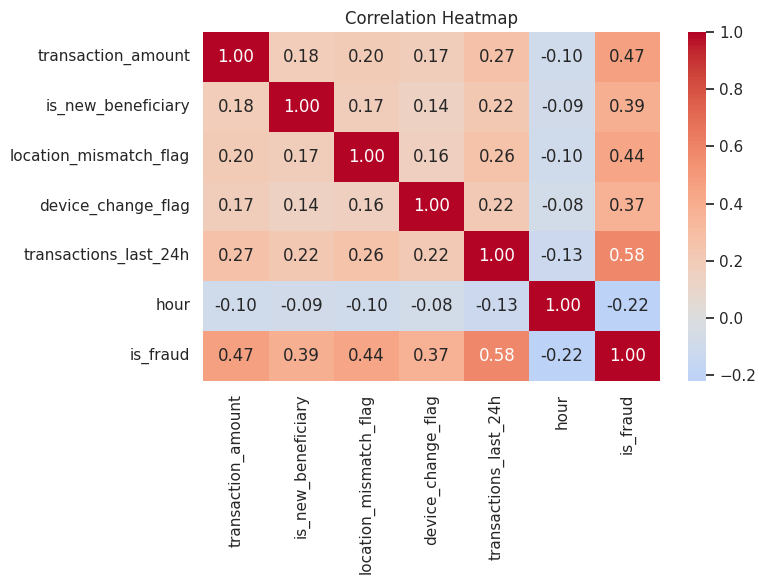

In [15]:
numeric_cols = ["transaction_amount", "is_new_beneficiary", "location_mismatch_flag",
                 "device_change_flag", "transactions_last_24h", "hour", "is_fraud"]

fig, ax = plt.subplots(figsize=(8, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../reports/figures/09_correlation_heatmap.png", dpi=150)
plt.show()